In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

# EMA 쓴 결과값 확인 코드

[Client A] raw → shape: (3300, 16), class balance: {0: 2831, 1: 469}
[Client B] raw → shape: (530, 16), class balance: {0: 474, 1: 56}
[Client C] raw → shape: (3245, 16), class balance: {0: 2915, 1: 330}
[Client D] raw → shape: (460, 16), class balance: {0: 406, 1: 54}
[Client A] train after SMOTE → shape: (3958, 16), class balance: {0: 1979, 1: 1979}
[Client A] val   (no SMOTE)   → shape: (330, 16), class balance: {0: 279, 1: 51}
[Client A] test  (no SMOTE)   → shape: (660, 16), class balance: {0: 573, 1: 87}
[Client B] train after SMOTE → shape: (664, 16), class balance: {0: 332, 1: 332}
[Client B] val   (no SMOTE)   → shape: (53, 16), class balance: {0: 48, 1: 5}
[Client B] test  (no SMOTE)   → shape: (106, 16), class balance: {0: 94, 1: 12}
[Client C] train after SMOTE → shape: (4100, 16), class balance: {1: 2050, 0: 2050}
[Client C] val   (no SMOTE)   → shape: (324, 16), class balance: {0: 285, 1: 39}
[Client C] test  (no SMOTE)   → shape: (650, 16), class balance: {0: 580, 1: 70}

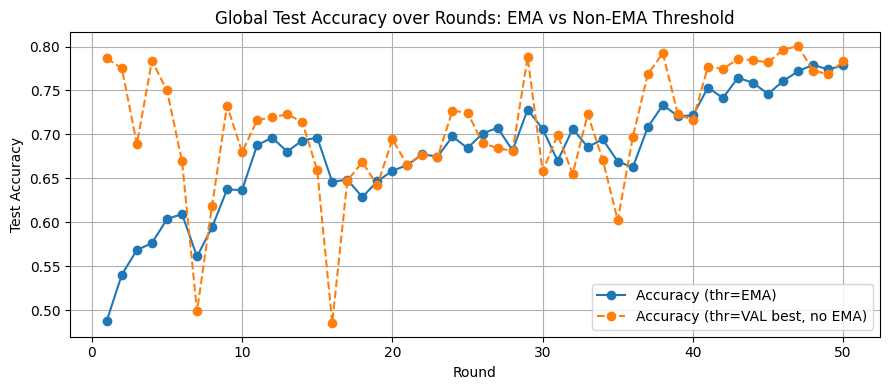

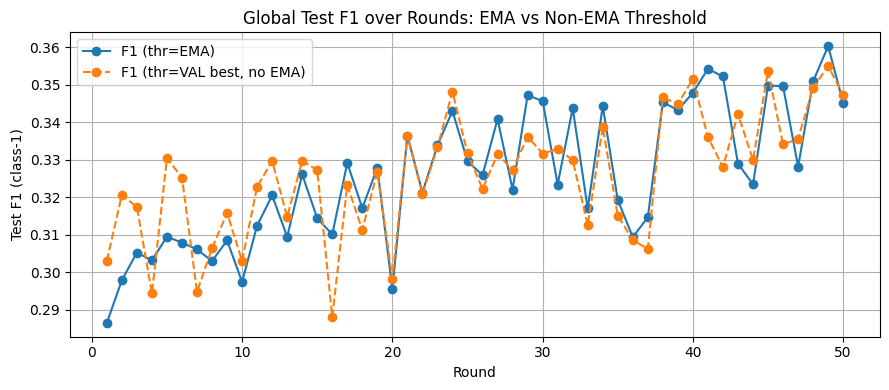

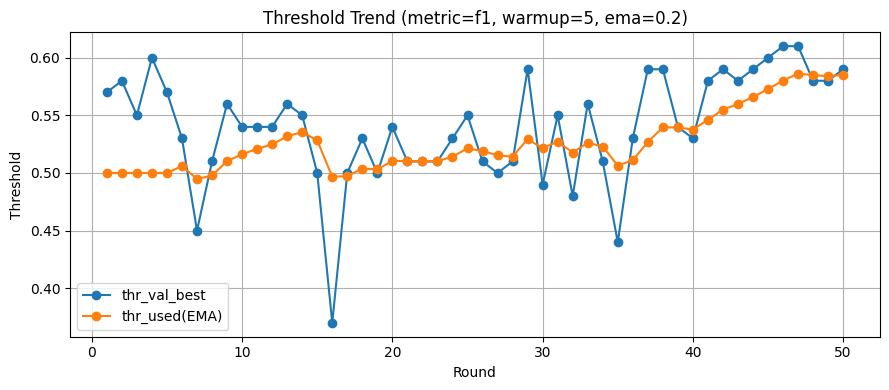


 Final Global Evaluation (EMA final thr)
Final thr_used(EMA)=0.59 | Acc=0.7785 | F1=0.3451 | ROC-AUC=0.7615 | pos_rate=0.221
CM: TN=1086, FP=245, FN=89, TP=88
              precision    recall  f1-score   support

           0     0.9243    0.8159    0.8667      1331
           1     0.2643    0.4972    0.3451       177

    accuracy                         0.7785      1508
   macro avg     0.5943    0.6566    0.6059      1508
weighted avg     0.8468    0.7785    0.8055      1508


 Per-Client Fine-tuning Report (thr=EMA final)

--- Client A Fine-tuning ---
[Client A] thr=0.59 | Acc=0.7515 | F1=0.3440 | ROC-AUC=0.7486 | pos_rate=0.247
CM: TN=453, FP=120, FN=44, TP=43
              precision    recall  f1-score   support

           0     0.9115    0.7906    0.8467       573
           1     0.2638    0.4943    0.3440        87

    accuracy                         0.7515       660
   macro avg     0.5876    0.6424    0.5954       660
weighted avg     0.8261    0.7515    0.7805       6

In [ ]:
# ============================================================
# Federated Learning (DeepMLP)
# + αᵢ Mitigation (n_i, c_i, t_i) softmax aggregation
# + Train-only SMOTE (per-client)
# + FocalLoss + FedProx + FedBN-style aggregation
# + Threshold tuning on VAL
# + Compare: EMA threshold vs Non-EMA threshold (thr_val_best)
# + Round logging: Global(Test) Acc/F1/CM for BOTH settings
# + Final: Global report + Per-client fine-tuning report (uses EMA final_thr)
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1'
]

# αᵢ hyperparams
RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) Data load + split + (SMOTE only on TRAIN)
# =========================================================
def load_excel_binary_raw(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    return X, y


def oversample_train_only(X_train, y_train, sampling_strategy=1.0, k_neighbors=5):
    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors, sampling_strategy=sampling_strategy)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res


def build_clients(path_map, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
                  smote_sampling_strategy=1.0, smote_k=5):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-9

    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary_raw(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] raw → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    cols = list(cols)

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat_all = v["X"][cols].copy()
        y_all = v["y"].astype(int)

        n = len(feat_all)
        idx = np.arange(n)
        rng = np.random.RandomState(SEED)
        rng.shuffle(idx)

        n_train = int(train_ratio * n)
        n_val   = int(val_ratio * n)

        tr_idx = idx[:n_train]
        va_idx = idx[n_train:n_train+n_val]
        te_idx = idx[n_train+n_val:]

        X_train_raw = feat_all.iloc[tr_idx].copy()
        y_train_raw = y_all[tr_idx]

        X_val_raw   = feat_all.iloc[va_idx].copy()
        y_val_raw   = y_all[va_idx]

        X_test_raw  = feat_all.iloc[te_idx].copy()
        y_test_raw  = y_all[te_idx]

        mu = X_train_raw.mean()
        sigma = X_train_raw.std().replace(0, 1)

        X_train_std = (X_train_raw - mu) / sigma
        X_val_std   = (X_val_raw   - mu) / sigma
        X_test_std  = (X_test_raw  - mu) / sigma

        X_train_sm, y_train_sm = oversample_train_only(
            X_train_std, y_train_raw,
            sampling_strategy=smote_sampling_strategy,
            k_neighbors=smote_k
        )

        print(f"[Client {cid}] train after SMOTE → shape: {X_train_sm.shape}, class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
        print(f"[Client {cid}] val   (no SMOTE)   → shape: {X_val_std.shape}, class balance: {pd.Series(y_val_raw).value_counts().to_dict()}")
        print(f"[Client {cid}] test  (no SMOTE)   → shape: {X_test_std.shape}, class balance: {pd.Series(y_test_raw).value_counts().to_dict()}")

        Xtr = torch.tensor(np.asarray(X_train_sm).astype(np.float32))
        ytr = torch.tensor(y_train_sm, dtype=torch.long)

        Xva = torch.tensor(np.asarray(X_val_std).astype(np.float32))
        yva = torch.tensor(y_val_raw, dtype=torch.long)

        Xte = torch.tensor(np.asarray(X_test_std).astype(np.float32))
        yte = torch.tensor(y_test_raw, dtype=torch.long)

        clients[cid] = {
            "train": TensorDataset(Xtr, ytr),
            "val":   TensorDataset(Xva, yva),
            "test":  TensorDataset(Xte, yte),
        }

        metas[cid] = {
            "n_samples_raw": int(len(y_all)),
            "train_class_counts_raw": pd.Series(y_train_raw).value_counts().to_dict(),
            "val_class_counts_raw":   pd.Series(y_val_raw).value_counts().to_dict(),
            "test_class_counts_raw":  pd.Series(y_test_raw).value_counts().to_dict(),
        }

    return clients, metas, cols


# =========================================================
# 2) Model
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ components + aggregation
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho, beta, theta, use_fedbn=True, alpha_temp=1.0):
    """
    αᵢ = softmax( (log(nᵢ^ρ)+log(cᵢ^β)+log(tᵢ^θ)) * alpha_temp )
    """
    logits = {}
    for cid, comp in alpha_components.items():
        s = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )
        logits[cid] = s * float(alpha_temp)

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            global_sd[k] = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items()).clone()

    return global_sd, alphas


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox = prox + torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) Predict + threshold search + evaluate
# =========================================================
def predict_probs(model, dataset, device):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probs_all, y_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.append(probs)
            y_all.append(y.numpy())

    return np.concatenate(probs_all), np.concatenate(y_all)


def find_best_threshold_from_probs(probs, y_true, metric="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

    best_t, best_score = 0.5, -1e18
    best_aux = -1e18

    for t in grid:
        y_pred = (probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_t = score, t

        elif metric == "recall":
            rec = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if rec > best_score or (rec == best_score and prec > best_aux):
                best_score, best_aux, best_t = rec, prec, t

        elif metric == "youden":
            cm = confusion_matrix(y_true, y_pred)
            if cm.size != 4:
                continue
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn + 1e-12)
            fpr = fp / (fp + tn + 1e-12)
            score = tpr - fpr
            if score > best_score:
                best_score, best_t = score, t
        else:
            raise ValueError("metric must be one of: f1, recall, youden")

    return float(best_t), float(best_score)


def evaluate_with_threshold(model, dataset, device, threshold):
    probs, y_true = predict_probs(model, dataset, device)
    y_pred = (probs >= threshold).astype(int)

    acc = float(np.mean(y_true == y_pred))
    f1  = float(f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    pos_rate = float(np.mean(y_pred))
    try:
        auc = float(roc_auc_score(y_true, probs))
    except Exception:
        auc = float("nan")

    return acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate


# =========================================================
# 7) Fine-tuning
# =========================================================
def finetune_local(model, train_ds, device, lr=8e-4, epochs=5):
    ft_model = copy.deepcopy(model).to(device)
    ft_model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(ft_model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = ft_model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

    return ft_model


# =========================================================
# 8) Main
# =========================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)

    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--lr", type=float, default=8e-4)
    parser.add_argument("--local_epochs", type=int, default=5)

    parser.add_argument("--smote_ratio", type=float, default=1.0)
    parser.add_argument("--smote_k", type=int, default=5)

    parser.add_argument("--alpha_temp", type=float, default=1.0)

    parser.add_argument("--th_metric", type=str, default="f1")        # f1 / recall / youden
    parser.add_argument("--thr_warmup", type=int, default=5)
    parser.add_argument("--thr_init", type=float, default=0.50)
    parser.add_argument("--thr_ema", type=float, default=0.20)
    parser.add_argument("--thr_grid_min", type=float, default=0.05)
    parser.add_argument("--thr_grid_max", type=float, default=0.95)
    parser.add_argument("--thr_grid_step", type=float, default=0.01)

    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    paths = {"A": "/content/A.xlsx", "B": "/content/B.xlsx", "C": "/content/C.xlsx", "D": "/content/D.xlsx"}
    clients, metas, cols = build_clients(
        paths,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
        smote_sampling_strategy=args.smote_ratio,
        smote_k=args.smote_k
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["train"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim).to(device)

    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    combined_val  = torch.utils.data.ConcatDataset([v["val"]  for v in clients.values()])
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    thr_grid = np.round(
        np.arange(args.thr_grid_min, args.thr_grid_max + 1e-12, args.thr_grid_step), 2
    )

    # -----------------------
    # Histories (EMA vs Non-EMA)
    # -----------------------
    rounds_axis = list(range(1, args.rounds + 1))

    thr_val_history      = []
    thr_used_history     = []

    # EMA applied
    acc_ema_history      = []
    f1_ema_history       = []
    posrate_ema_history  = []

    # Non-EMA (direct val-best threshold each round)
    acc_noema_history    = []
    f1_noema_history     = []
    posrate_noema_history= []

    alpha_history        = []

    # EMA threshold state
    thr_used = float(args.thr_init)

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        print(" Participating:", selected)

        state_dicts = {}
        alpha_components = {}
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # local train
        for cid in selected:
            ds_train = clients[cid]["train"]
            class_counts_raw = metas[cid]["train_class_counts_raw"]

            sd = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=args.lr,
                epochs=args.local_epochs,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            n_i = math.sqrt(metas[cid]["n_samples_raw"])
            c_i = compute_ci(class_counts_raw)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        new_global_sd, alphas = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO, beta=BETA, theta=THETA,
            use_fedbn=True,
            alpha_temp=args.alpha_temp
        )
        global_model.load_state_dict(new_global_sd)
        alpha_history.append((rnd, alphas))

        # ----- threshold tuning on VAL -----
        val_probs, val_true = predict_probs(global_model, combined_val, device)
        thr_val_best, thr_val_score = find_best_threshold_from_probs(
            val_probs, val_true, metric=args.th_metric, grid=thr_grid
        )
        thr_val_history.append(thr_val_best)

        # ----- EMA threshold update (after warmup) -----
        if rnd <= args.thr_warmup:
            thr_used = float(args.thr_init)
        else:
            lam = float(args.thr_ema)
            thr_used = (1.0 - lam) * thr_used + lam * thr_val_best

        thr_used_history.append(float(thr_used))

        # ==========================
        # Evaluate on TEST (EMA)
        # ==========================
        acc_e, f1_e, auc_e, (tn_e, fp_e, fn_e, tp_e), _, _, pos_e = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_used)
        )
        acc_ema_history.append(acc_e)
        f1_ema_history.append(f1_e)
        posrate_ema_history.append(pos_e)

        # ==========================
        # Evaluate on TEST (Non-EMA)
        # ==========================
        acc_n, f1_n, auc_n, (tn_n, fp_n, fn_n, tp_n), _, _, pos_n = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_val_best)
        )
        acc_noema_history.append(acc_n)
        f1_noema_history.append(f1_n)
        posrate_noema_history.append(pos_n)

        print(f"[Round {rnd}] alpha_temp={args.alpha_temp:.2f}, mu={args.mu:.4f}")
        print(f"[Round {rnd}] VAL tuned thr({args.th_metric})={thr_val_best:.2f} (score={thr_val_score:.4f}) | EMA thr_used={thr_used:.2f}")
        print(f"[Round {rnd}] TEST (EMA)    Acc={acc_e:.4f}, F1={f1_e:.4f}, AUC={auc_e:.4f}, TN={tn_e}, FP={fp_e}, FN={fn_e}, TP={tp_e}, pos_rate={pos_e:.3f}")
        print(f"[Round {rnd}] TEST (NoEMA)  Acc={acc_n:.4f}, F1={f1_n:.4f}, AUC={auc_n:.4f}, TN={tn_n}, FP={fp_n}, FN={fn_n}, TP={tp_n}, pos_rate={pos_n:.3f}")

    # =========================
    # Plots: Accuracy (EMA vs Non-EMA)
    # =========================
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, acc_ema_history, marker='o', label="Accuracy (thr=EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test Accuracy")
    plt.title("Global Test Accuracy over Rounds: EMA vs Non-EMA Threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (선택) F1도 같이 비교하고 싶으면 유지
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, f1_ema_history, marker='o', label="F1 (thr=EMA)")
    plt.plot(rounds_axis, f1_noema_history, linestyle='--', marker='o', label="F1 (thr=VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test F1 (class-1)")
    plt.title("Global Test F1 over Rounds: EMA vs Non-EMA Threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Threshold trend
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, thr_val_history, marker='o', label="thr_val_best")
    plt.plot(rounds_axis, thr_used_history, marker='o', label="thr_used(EMA)")
    plt.xlabel("Round")
    plt.ylabel("Threshold")
    plt.title(f"Threshold Trend (metric={args.th_metric}, warmup={args.thr_warmup}, ema={args.thr_ema})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================
    # Final Global Report (EMA final threshold)
    # =========================
    final_thr = float(thr_used_history[-1]) if len(thr_used_history) else float(args.thr_init)
    acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate = evaluate_with_threshold(
        global_model, combined_test, device, threshold=final_thr
    )
    print("\n==============================")
    print(" Final Global Evaluation (EMA final thr)")
    print("==============================")
    print(f"Final thr_used(EMA)={final_thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | ROC-AUC={auc:.4f} | pos_rate={pos_rate:.3f}")
    print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    # =========================
    # Per-client Fine-tuning (thr fixed to EMA final_thr)
    # =========================
    print("\n==============================")
    print(" Per-Client Fine-tuning Report (thr=EMA final)")
    print("==============================")

    for cid in clients.keys():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_model = finetune_local(
            model=global_model,
            train_ds=clients[cid]["train"],
            device=device,
            lr=args.lr,
            epochs=args.ft_epochs
        )

        acc_c, f1_c, auc_c, (tn_c, fp_c, fn_c, tp_c), ytc, ypc, pos_rate_c = evaluate_with_threshold(
            ft_model, clients[cid]["test"], device, threshold=final_thr
        )
        print(f"[Client {cid}] thr={final_thr:.2f} | Acc={acc_c:.4f} | F1={f1_c:.4f} | ROC-AUC={auc_c:.4f} | pos_rate={pos_rate_c:.3f}")
        print(f"CM: TN={tn_c}, FP={fp_c}, FN={fn_c}, TP={tp_c}")
        print(classification_report(ytc, ypc, digits=4, zero_division=0))


# 최종 찐찐 모델

[Client A] raw → shape: (3300, 16), class balance: {0: 2831, 1: 469}
[Client B] raw → shape: (530, 16), class balance: {0: 474, 1: 56}
[Client C] raw → shape: (3245, 16), class balance: {0: 2915, 1: 330}
[Client D] raw → shape: (460, 16), class balance: {0: 406, 1: 54}
[Client A] train after SMOTE(borderline(k=5, ratio=0.8)) → shape: (3562, 16), class balance: {0: 1979, 1: 1583}
[Client A] val   (no SMOTE)              → shape: (330, 16), class balance: {0: 279, 1: 51}
[Client A] test  (no SMOTE)              → shape: (660, 16), class balance: {0: 573, 1: 87}
[Client B] train after SMOTE(borderline(k=5, ratio=0.8)) → shape: (597, 16), class balance: {0: 332, 1: 265}
[Client B] val   (no SMOTE)              → shape: (53, 16), class balance: {0: 48, 1: 5}
[Client B] test  (no SMOTE)              → shape: (106, 16), class balance: {0: 94, 1: 12}
[Client C] train after SMOTE(borderline(k=5, ratio=0.8)) → shape: (3690, 16), class balance: {0: 2050, 1: 1640}
[Client C] val   (no SMOTE)      

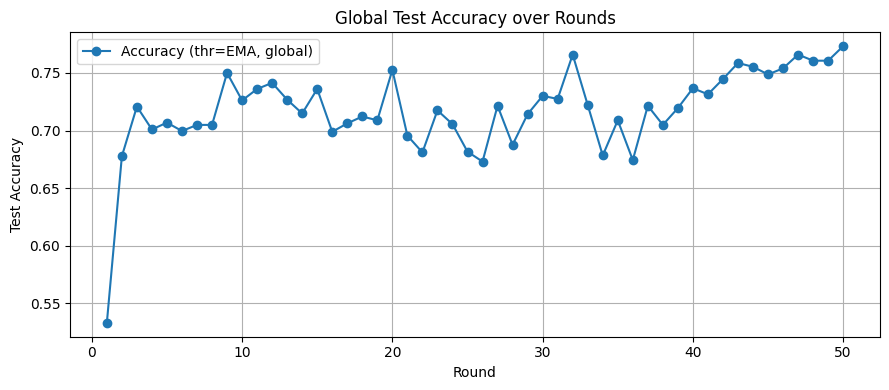

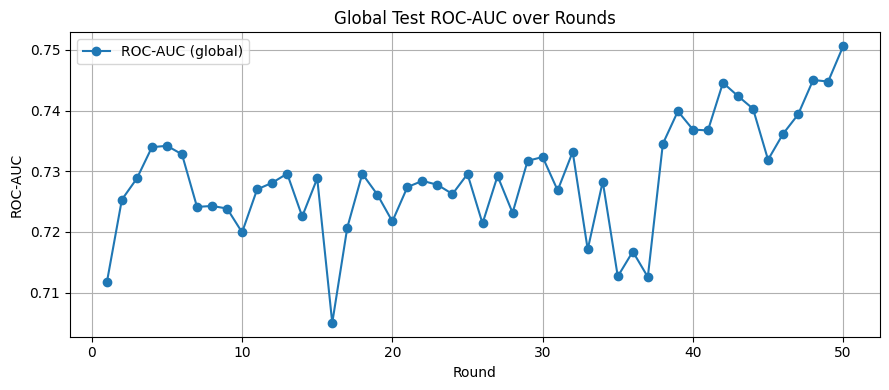

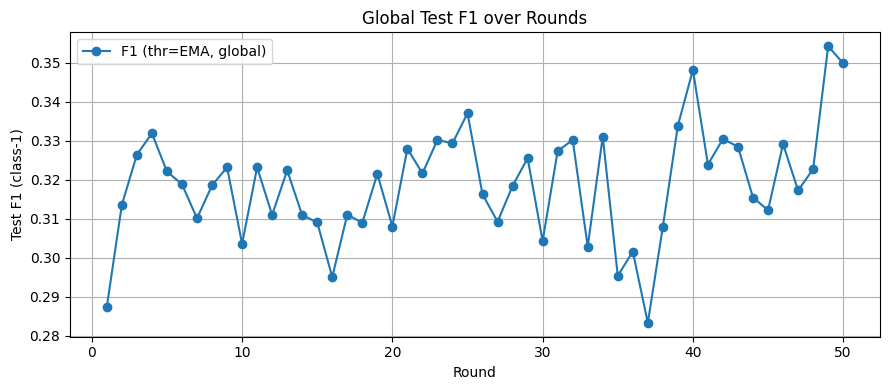

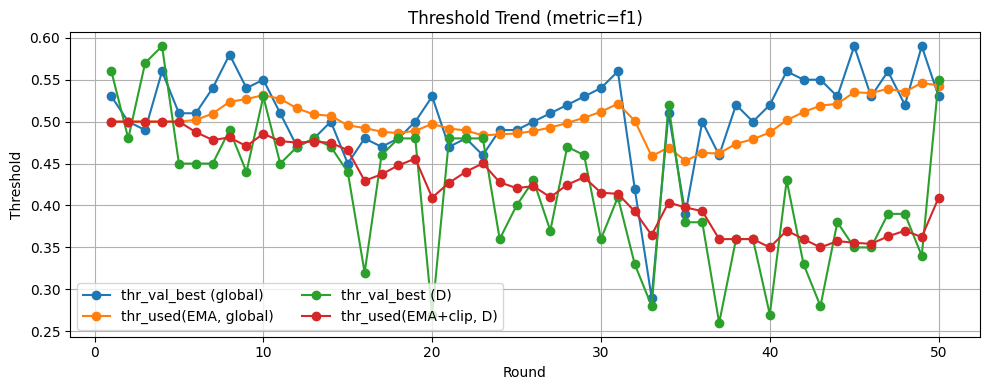

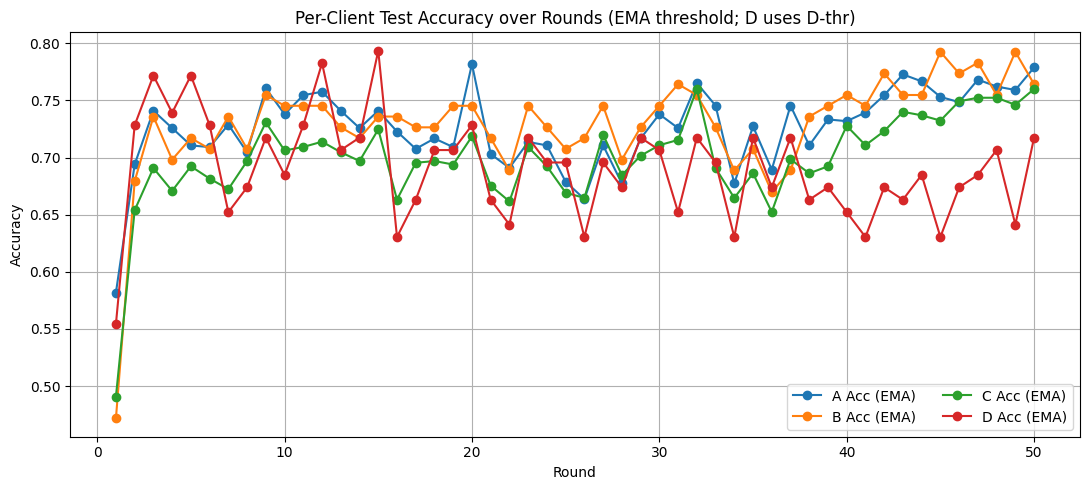

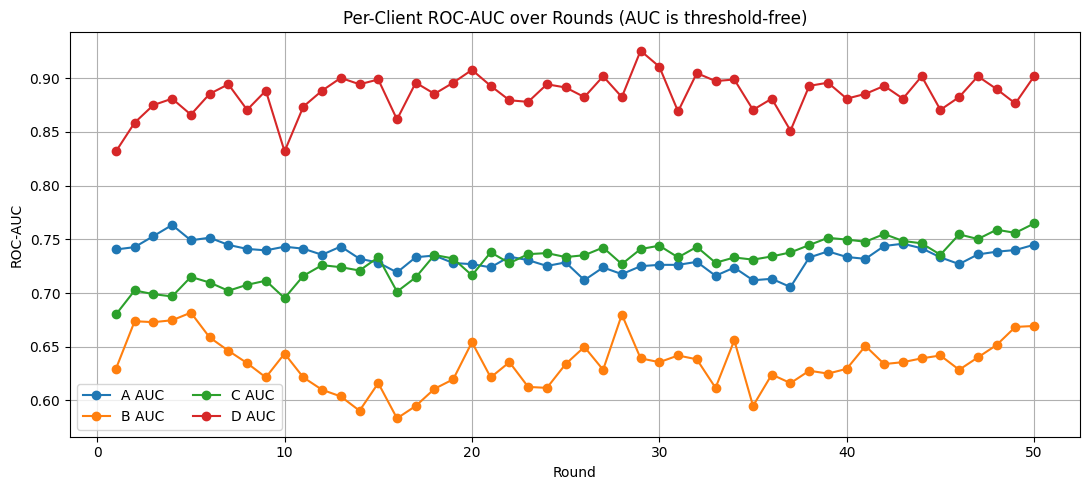


 Final Global Evaluation (EMA final thr)
Final thr_used(EMA, global)=0.54 | Acc=0.7732 | F1=0.3498 | ROC-AUC=0.7506 | pos_rate=0.231
CM: TN=1074, FP=257, FN=85, TP=92
              precision    recall  f1-score   support

           0     0.9267    0.8069    0.8627      1331
           1     0.2636    0.5198    0.3498       177

    accuracy                         0.7732      1508
   macro avg     0.5951    0.6633    0.6062      1508
weighted avg     0.8488    0.7732    0.8025      1508



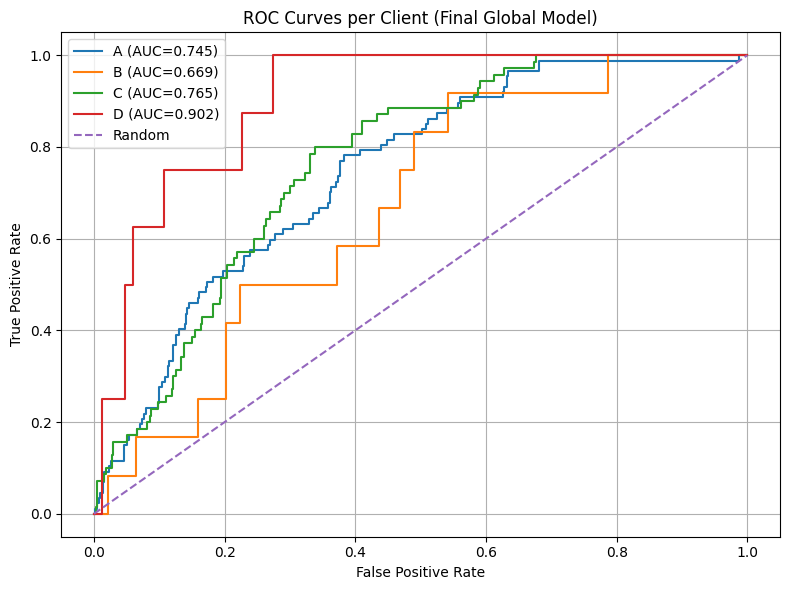


 Per-Client Fine-tuning Report (thr=EMA final; global thr)

--- Client A Fine-tuning ---
[Client A] thr=0.54 | Acc=0.7621 | F1=0.3644 | ROC-AUC=0.7393 | pos_rate=0.242
CM: TN=458, FP=115, FN=42, TP=45
              precision    recall  f1-score   support

           0     0.9160    0.7993    0.8537       573
           1     0.2812    0.5172    0.3644        87

    accuracy                         0.7621       660
   macro avg     0.5986    0.6583    0.6090       660
weighted avg     0.8323    0.7621    0.7892       660


--- Client B Fine-tuning ---
[Client B] thr=0.54 | Acc=0.7925 | F1=0.2143 | ROC-AUC=0.7225 | pos_rate=0.151
CM: TN=81, FP=13, FN=9, TP=3
              precision    recall  f1-score   support

           0     0.9000    0.8617    0.8804        94
           1     0.1875    0.2500    0.2143        12

    accuracy                         0.7925       106
   macro avg     0.5437    0.5559    0.5474       106
weighted avg     0.8193    0.7925    0.8050       106


--- C

In [10]:
# ============================================================
# Federated Learning (DeepMLP)
# + αᵢ Mitigation (n_i, c_i, t_i) softmax aggregation
# + Train-only "Proper SMOTE" (per-client)
#   - BorderlineSMOTE default + safe fallback
#   - (NEW) Client D uses its own SMOTE ratio (lighter) for stability
# + FocalLoss + FedProx + FedBN-style aggregation
# + Threshold tuning on VAL
# + Compare: EMA threshold vs Non-EMA threshold (thr_val_best)
# + Round logging: Global(Test) Acc/F1/AUC/CM for BOTH settings
# + Per-client per-round Acc + AUC histories + plots
#   - (NEW) D uses D-threshold (EMA+clip) for its per-round Acc
# + Final: Global report + Per-client fine-tuning report (uses EMA final_thr)
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score,
    classification_report, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
import matplotlib.pyplot as plt

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1'
]

# αᵢ hyperparams
RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) Data load + split + (SMOTE only on TRAIN)
# =========================================================
def load_excel_binary_raw(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨 컬럼이 없으면 0으로 채움
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 다중 결함 -> 이진화(하나라도 결함이면 1)
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # feature는 numeric만 + inf 제거 + NaN drop
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )

    # X에서 dropna로 행이 줄었을 수 있으니 y도 길이 맞춤(원래 코드 유지)
    y = y[:len(X)]
    return X, y


def _safe_k_neighbors(y_train, desired_k):
    """SMOTE 계열은 minority_count > k_neighbors 여야 함. 안전하게 k 조정."""
    y = np.asarray(y_train).astype(int)
    counts = np.bincount(y, minlength=2)
    n_min = int(counts[1])
    if n_min <= 1:
        return None  # SMOTE 불가
    k = min(int(desired_k), n_min - 1)
    k = max(1, k)
    return k


def oversample_train_only(
    X_train, y_train,
    smote_kind="borderline",  # "borderline" | "regular"
    sampling_strategy=0.8,    # minority를 majority의 0.8배까지 맞춤
    k_neighbors=5
):
    """
    '제대로 된 SMOTE' 포인트
    - TRAIN에만 적용
    - minority 샘플 수가 작으면 k_neighbors 자동 축소 / 불가 시 skip
    - BorderlineSMOTE 기본
    - sampling_strategy 과대(1.0)는 FP 폭증/Accuracy 착시가 생길 수 있어 0.6~0.9 권장
    """
    y = np.asarray(y_train).astype(int)
    counts = np.bincount(y, minlength=2)
    n0, n1 = int(counts[0]), int(counts[1])

    k = _safe_k_neighbors(y, k_neighbors)
    if k is None:
        return X_train, y_train, "skip(minority<=1)"

    if n1 == 0 or n0 == 0:
        return X_train, y_train, "skip(single-class)"

    # 이미 충분히 균형이면 SMOTE 생략
    if n1 >= int(n0 * sampling_strategy):
        return X_train, y_train, "skip(already-balanced-enough)"

    if smote_kind == "borderline":
        sm = BorderlineSMOTE(
            random_state=SEED,
            k_neighbors=k,
            sampling_strategy=sampling_strategy,
            kind="borderline-1"
        )
        tag = f"borderline(k={k}, ratio={sampling_strategy})"
    else:
        sm = SMOTE(
            random_state=SEED,
            k_neighbors=k,
            sampling_strategy=sampling_strategy
        )
        tag = f"regular(k={k}, ratio={sampling_strategy})"

    X_res, y_res = sm.fit_resample(X_train, y)
    return X_res, y_res, tag


def build_clients(
    path_map,
    train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
    smote_kind="borderline",
    smote_sampling_strategy=0.8,
    smote_k=5,
    # (NEW) D 전용 SMOTE 비율
    d_smote_sampling_strategy=None
):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-9

    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary_raw(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] raw → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 feature만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    cols = list(cols)

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat_all = v["X"][cols].copy()
        y_all = v["y"].astype(int)

        n = len(feat_all)
        idx = np.arange(n)
        rng = np.random.RandomState(SEED)
        rng.shuffle(idx)

        n_train = int(train_ratio * n)
        n_val   = int(val_ratio * n)

        tr_idx = idx[:n_train]
        va_idx = idx[n_train:n_train+n_val]
        te_idx = idx[n_train+n_val:]

        X_train_raw = feat_all.iloc[tr_idx].copy()
        y_train_raw = y_all[tr_idx]

        X_val_raw   = feat_all.iloc[va_idx].copy()
        y_val_raw   = y_all[va_idx]

        X_test_raw  = feat_all.iloc[te_idx].copy()
        y_test_raw  = y_all[te_idx]

        #  표준화는 TRAIN 통계로만(누수 방지)
        mu = X_train_raw.mean()
        sigma = X_train_raw.std().replace(0, 1)

        X_train_std = (X_train_raw - mu) / sigma
        X_val_std   = (X_val_raw   - mu) / sigma
        X_test_std  = (X_test_raw  - mu) / sigma

        # (NEW) D만 SMOTE ratio를 더 약하게
        ratio_here = smote_sampling_strategy
        if (cid == "D") and (d_smote_sampling_strategy is not None):
            ratio_here = float(d_smote_sampling_strategy)

        X_train_sm, y_train_sm, smote_tag = oversample_train_only(
            X_train_std, y_train_raw,
            smote_kind=smote_kind,
            sampling_strategy=ratio_here,
            k_neighbors=smote_k
        )

        print(f"[Client {cid}] train after SMOTE({smote_tag}) → shape: {np.asarray(X_train_sm).shape}, class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
        print(f"[Client {cid}] val   (no SMOTE)              → shape: {X_val_std.shape}, class balance: {pd.Series(y_val_raw).value_counts().to_dict()}")
        print(f"[Client {cid}] test  (no SMOTE)              → shape: {X_test_std.shape}, class balance: {pd.Series(y_test_raw).value_counts().to_dict()}")

        Xtr = torch.tensor(np.asarray(X_train_sm).astype(np.float32))
        ytr = torch.tensor(np.asarray(y_train_sm).astype(np.int64), dtype=torch.long)

        Xva = torch.tensor(np.asarray(X_val_std).astype(np.float32))
        yva = torch.tensor(np.asarray(y_val_raw).astype(np.int64), dtype=torch.long)

        Xte = torch.tensor(np.asarray(X_test_std).astype(np.float32))
        yte = torch.tensor(np.asarray(y_test_raw).astype(np.int64), dtype=torch.long)

        clients[cid] = {
            "train": TensorDataset(Xtr, ytr),
            "val":   TensorDataset(Xva, yva),
            "test":  TensorDataset(Xte, yte),
        }

        metas[cid] = {
            "n_samples_raw": int(len(y_all)),
            "train_class_counts_raw": pd.Series(y_train_raw).value_counts().to_dict(),
            "val_class_counts_raw":   pd.Series(y_val_raw).value_counts().to_dict(),
            "test_class_counts_raw":  pd.Series(y_test_raw).value_counts().to_dict(),
        }

    return clients, metas, cols


# =========================================================
# 2) Model
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss (binary in CE form)
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ components + aggregation
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)
    logK = math.log(K + 1e-12)

    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(
    state_dicts, alpha_components, rho, beta, theta,
    use_fedbn=True, alpha_temp=1.0,
    # (NEW) alpha cap (특히 D 흔들림 완화용)
    alpha_cap_by_client=None
):
    """
    αᵢ = softmax( (log(nᵢ^ρ)+log(cᵢ^β)+log(tᵢ^θ)) * alpha_temp )
    + (NEW) 특정 클라이언트 alpha 상한(cap)
    """
    logits = {}
    for cid, comp in alpha_components.items():
        s = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )
        logits[cid] = s * float(alpha_temp)

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    # (NEW) cap 적용 후 재정규화
    if alpha_cap_by_client:
        capped = {}
        for cid, a in alphas.items():
            cap = alpha_cap_by_client.get(cid, None)
            if cap is None:
                capped[cid] = a
            else:
                capped[cid] = min(float(a), float(cap))
        s = sum(capped.values())
        if s > 0:
            alphas = {cid: capped[cid] / s for cid in capped}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            global_sd[k] = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items()).clone()

    return global_sd, alphas


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox = prox + torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) Predict + threshold search + evaluate
# =========================================================
def predict_probs(model, dataset, device):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probs_all, y_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.append(probs)
            y_all.append(y.numpy())

    return np.concatenate(probs_all), np.concatenate(y_all)


def find_best_threshold_from_probs(probs, y_true, metric="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

    best_t, best_score = 0.5, -1e18
    best_aux = -1e18

    for t in grid:
        y_pred = (probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_t = score, t

        elif metric == "recall":
            rec = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if rec > best_score or (rec == best_score and prec > best_aux):
                best_score, best_aux, best_t = rec, prec, t

        elif metric == "youden":
            cm = confusion_matrix(y_true, y_pred)
            if cm.size != 4:
                continue
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn + 1e-12)
            fpr = fp / (fp + tn + 1e-12)
            score = tpr - fpr
            if score > best_score:
                best_score, best_t = score, t
        else:
            raise ValueError("metric must be one of: f1, recall, youden")

    return float(best_t), float(best_score)


def evaluate_with_threshold(model, dataset, device, threshold):
    probs, y_true = predict_probs(model, dataset, device)
    y_pred = (probs >= threshold).astype(int)

    acc = float(np.mean(y_true == y_pred))
    f1  = float(f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    pos_rate = float(np.mean(y_pred))
    try:
        auc = float(roc_auc_score(y_true, probs))
    except Exception:
        auc = float("nan")

    return acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate


def compute_auc_and_probs(model, dataset, device):
    probs, y_true = predict_probs(model, dataset, device)
    try:
        auc = float(roc_auc_score(y_true, probs))
    except Exception:
        auc = float("nan")
    return auc, probs, y_true


def clip(x, lo, hi):
    return float(max(lo, min(hi, x)))


# =========================================================
# 7) Fine-tuning
# =========================================================
def finetune_local(model, train_ds, device, lr=8e-4, epochs=5):
    ft_model = copy.deepcopy(model).to(device)
    ft_model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(ft_model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = ft_model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

    return ft_model


# =========================================================
# 8) Main
# =========================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)

    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--lr", type=float, default=8e-4)
    parser.add_argument("--local_epochs", type=int, default=5)

    #  SMOTE controls
    parser.add_argument("--smote_kind", type=str, default="borderline", choices=["borderline", "regular"])
    parser.add_argument("--smote_ratio", type=float, default=0.8)     # A/B/C 기본
    parser.add_argument("--smote_k", type=int, default=5)
    # (NEW) D는 더 약하게 (안정화)
    parser.add_argument("--d_smote_ratio", type=float, default=0.6)   # 0.5~0.7 추천

    parser.add_argument("--alpha_temp", type=float, default=1.0)
    # (NEW) D alpha cap (aggregation 흔들림 완화)
    parser.add_argument("--cap_alpha_D", type=float, default=0.0)     # 0이면 cap off, 예: 0.35

    # Threshold tuning (global)
    parser.add_argument("--th_metric", type=str, default="f1")        # f1 / recall / youden
    parser.add_argument("--thr_warmup", type=int, default=5)
    parser.add_argument("--thr_init", type=float, default=0.50)
    parser.add_argument("--thr_ema", type=float, default=0.20)
    parser.add_argument("--thr_grid_min", type=float, default=0.05)
    parser.add_argument("--thr_grid_max", type=float, default=0.95)
    parser.add_argument("--thr_grid_step", type=float, default=0.01)

    # (NEW) D threshold (EMA+clip) for stability
    parser.add_argument("--d_thr_ema", type=float, default=0.25)
    parser.add_argument("--d_thr_clip_lo", type=float, default=0.35)
    parser.add_argument("--d_thr_clip_hi", type=float, default=0.65)

    # Fine-tuning
    parser.add_argument("--ft_epochs", type=int, default=5)

    # Plot options
    parser.add_argument("--plot_noema", type=int, default=0)      # 0이면 주황색(Non-EMA) 라인 제거
    parser.add_argument("--plot_roc_final", type=int, default=1)

    args, _ = parser.parse_known_args()

    def pick_path(fname):
        p1 = os.path.join("/mnt/data", fname)
        p2 = os.path.join("/content", fname)
        if os.path.exists(p1):
            return p1
        return p2

    paths = {"A": pick_path("A.xlsx"), "B": pick_path("B.xlsx"), "C": pick_path("C.xlsx"), "D": pick_path("D.xlsx")}

    clients, metas, cols = build_clients(
        paths,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
        smote_kind=args.smote_kind,
        smote_sampling_strategy=args.smote_ratio,
        smote_k=args.smote_k,
        d_smote_sampling_strategy=args.d_smote_ratio
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["train"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim).to(device)

    # 참여 확률(너 설정 유지)
    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    combined_val  = torch.utils.data.ConcatDataset([v["val"]  for v in clients.values()])
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    thr_grid = np.round(
        np.arange(args.thr_grid_min, args.thr_grid_max + 1e-12, args.thr_grid_step), 2
    )

    # -----------------------
    # Histories (EMA vs Non-EMA)
    # -----------------------
    rounds_axis = list(range(1, args.rounds + 1))

    thr_val_history      = []
    thr_used_history     = []

    # (NEW) D threshold histories
    d_thr_val_history    = []
    d_thr_used_history   = []

    # EMA applied (global)
    acc_ema_history      = []
    f1_ema_history       = []
    auc_ema_history      = []
    posrate_ema_history  = []

    # Non-EMA
    acc_noema_history    = []
    f1_noema_history     = []
    auc_noema_history    = []
    posrate_noema_history= []

    alpha_history        = []

    # Per-client per-round histories
    client_ids = list(clients.keys())
    client_acc_ema_hist   = {cid: [] for cid in client_ids}
    client_auc_ema_hist   = {cid: [] for cid in client_ids}
    client_acc_noema_hist = {cid: [] for cid in client_ids}
    client_auc_noema_hist = {cid: [] for cid in client_ids}

    # EMA threshold state (global)
    thr_used = float(args.thr_init)
    # (NEW) EMA threshold state (D)
    d_thr_used = float(args.thr_init)

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        print(" Participating:", selected)

        state_dicts = {}
        alpha_components = {}
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # local train
        for cid in selected:
            ds_train = clients[cid]["train"]
            class_counts_raw = metas[cid]["train_class_counts_raw"]

            sd = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=args.lr,
                epochs=args.local_epochs,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            n_i = math.sqrt(metas[cid]["n_samples_raw"])
            c_i = compute_ci(class_counts_raw)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        alpha_cap = None
        if args.cap_alpha_D and float(args.cap_alpha_D) > 0:
            alpha_cap = {"D": float(args.cap_alpha_D)}

        new_global_sd, alphas = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO, beta=BETA, theta=THETA,
            use_fedbn=True,
            alpha_temp=args.alpha_temp,
            alpha_cap_by_client=alpha_cap
        )
        global_model.load_state_dict(new_global_sd)
        alpha_history.append((rnd, alphas))

        # ----- threshold tuning on VAL (global) -----
        val_probs, val_true = predict_probs(global_model, combined_val, device)
        thr_val_best, thr_val_score = find_best_threshold_from_probs(
            val_probs, val_true, metric=args.th_metric, grid=thr_grid
        )
        thr_val_history.append(thr_val_best)

        # ----- EMA threshold update (global) -----
        if rnd <= args.thr_warmup:
            thr_used = float(args.thr_init)
        else:
            lam = float(args.thr_ema)
            thr_used = (1.0 - lam) * thr_used + lam * thr_val_best
        thr_used_history.append(float(thr_used))

        # ----- (NEW) D threshold tuning on D-VAL + EMA+clip -----
        d_val_probs, d_val_true = predict_probs(global_model, clients["D"]["val"], device)
        d_thr_val_best, d_thr_val_score = find_best_threshold_from_probs(
            d_val_probs, d_val_true, metric=args.th_metric, grid=thr_grid
        )
        d_thr_val_history.append(d_thr_val_best)

        if rnd <= args.thr_warmup:
            d_thr_used = float(args.thr_init)
        else:
            lamd = float(args.d_thr_ema)
            d_thr_used = (1.0 - lamd) * d_thr_used + lamd * d_thr_val_best
            d_thr_used = clip(d_thr_used, float(args.d_thr_clip_lo), float(args.d_thr_clip_hi))
        d_thr_used_history.append(float(d_thr_used))

        # ==========================
        # Evaluate on TEST (EMA, global thr)
        # ==========================
        acc_e, f1_e, auc_e, (tn_e, fp_e, fn_e, tp_e), _, _, pos_e = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_used)
        )
        acc_ema_history.append(acc_e)
        f1_ema_history.append(f1_e)
        auc_ema_history.append(auc_e)
        posrate_ema_history.append(pos_e)

        # ==========================
        # Evaluate on TEST (Non-EMA, thr_val_best)
        # ==========================
        acc_n, f1_n, auc_n, (tn_n, fp_n, fn_n, tp_n), _, _, pos_n = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_val_best)
        )
        acc_noema_history.append(acc_n)
        f1_noema_history.append(f1_n)
        auc_noema_history.append(auc_n)
        posrate_noema_history.append(pos_n)

        # ==========================
        # Per-client evaluation each round
        #  - (NEW) D는 Acc 계산에 D-thr_used 사용
        #  - AUC는 threshold-free라 그대로
        # ==========================
        for cid in client_ids:
            thr_for_c = float(d_thr_used) if cid == "D" else float(thr_used)

            acc_c_e, _, auc_c_e, _, _, _, _ = evaluate_with_threshold(
                global_model, clients[cid]["test"], device, threshold=thr_for_c
            )
            client_acc_ema_hist[cid].append(acc_c_e)
            client_auc_ema_hist[cid].append(auc_c_e)

            acc_c_n, _, auc_c_n, _, _, _, _ = evaluate_with_threshold(
                global_model, clients[cid]["test"], device, threshold=float(thr_val_best)
            )
            client_acc_noema_hist[cid].append(acc_c_n)
            client_auc_noema_hist[cid].append(auc_c_n)

        cap_msg = f", cap_alpha_D={args.cap_alpha_D:.2f}" if (args.cap_alpha_D and float(args.cap_alpha_D) > 0) else ""
        print(f"[Round {rnd}] SMOTE={args.smote_kind}, ABC_ratio={args.smote_ratio:.2f}, D_ratio={args.d_smote_ratio:.2f} | alpha_temp={args.alpha_temp:.2f}, mu={args.mu:.4f}{cap_msg}")
        print(f"[Round {rnd}] VAL thr({args.th_metric})={thr_val_best:.2f} (score={thr_val_score:.4f}) | EMA thr_used={thr_used:.2f}")
        print(f"[Round {rnd}] D-VAL thr({args.th_metric})={d_thr_val_best:.2f} (score={d_thr_val_score:.4f}) | D-EMA thr_used={d_thr_used:.2f} (clip=[{args.d_thr_clip_lo:.2f},{args.d_thr_clip_hi:.2f}])")
        print(f"[Round {rnd}] TEST (EMA, global thr)   Acc={acc_e:.4f}, F1={f1_e:.4f}, AUC={auc_e:.4f}, TN={tn_e}, FP={fp_e}, FN={fn_e}, TP={tp_e}, pos_rate={pos_e:.3f}")
        print(f"[Round {rnd}] TEST (NoEMA, val thr)    Acc={acc_n:.4f}, F1={f1_n:.4f}, AUC={auc_n:.4f}, TN={tn_n}, FP={fp_n}, FN={fn_n}, TP={tp_n}, pos_rate={pos_n:.3f}")

    # =========================================================
    # Plots: Global Accuracy (기본: EMA만 표시)
    # =========================================================
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, acc_ema_history, marker='o', label="Accuracy (thr=EMA, global)")
    if int(args.plot_noema) == 1:
        plt.plot(rounds_axis, acc_noema_history, linestyle='--', marker='o', label="Accuracy (thr=VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test Accuracy")
    plt.title("Global Test Accuracy over Rounds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Global ROC-AUC
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, auc_ema_history, marker='o', label="ROC-AUC (global)")
    if int(args.plot_noema) == 1:
        plt.plot(rounds_axis, auc_noema_history, linestyle='--', marker='o', label="ROC-AUC (VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("ROC-AUC")
    plt.title("Global Test ROC-AUC over Rounds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Global F1
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, f1_ema_history, marker='o', label="F1 (thr=EMA, global)")
    if int(args.plot_noema) == 1:
        plt.plot(rounds_axis, f1_noema_history, linestyle='--', marker='o', label="F1 (thr=VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test F1 (class-1)")
    plt.title("Global Test F1 over Rounds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Threshold trend (global + D)
    plt.figure(figsize=(10,4))
    plt.plot(rounds_axis, thr_val_history, marker='o', label="thr_val_best (global)")
    plt.plot(rounds_axis, thr_used_history, marker='o', label="thr_used(EMA, global)")
    plt.plot(rounds_axis, d_thr_val_history, marker='o', label="thr_val_best (D)")
    plt.plot(rounds_axis, d_thr_used_history, marker='o', label="thr_used(EMA+clip, D)")
    plt.xlabel("Round")
    plt.ylabel("Threshold")
    plt.title(f"Threshold Trend (metric={args.th_metric})")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # =========================================================
    # Per-client Accuracy over rounds (EMA)
    #  - D는 D-thr_used로 Acc 계산됨
    # =========================================================
    plt.figure(figsize=(11,5))
    for cid in client_ids:
        plt.plot(rounds_axis, client_acc_ema_hist[cid], marker='o', label=f"{cid} Acc (EMA)")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.title("Per-Client Test Accuracy over Rounds (EMA threshold; D uses D-thr)")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    if int(args.plot_noema) == 1:
        plt.figure(figsize=(11,5))
        for cid in client_ids:
            plt.plot(rounds_axis, client_acc_noema_hist[cid], linestyle='--', marker='o', label=f"{cid} Acc (No-EMA)")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.title("Per-Client Test Accuracy over Rounds (VAL-best threshold, No-EMA)")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    # =========================================================
    # Per-client ROC-AUC over rounds (threshold-free)
    # =========================================================
    plt.figure(figsize=(11,5))
    for cid in client_ids:
        plt.plot(rounds_axis, client_auc_ema_hist[cid], marker='o', label=f"{cid} AUC")
    plt.xlabel("Round")
    plt.ylabel("ROC-AUC")
    plt.title("Per-Client ROC-AUC over Rounds (AUC is threshold-free)")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # =========================================================
    # Final Global Report (EMA final threshold)
    # =========================================================
    final_thr = float(thr_used_history[-1]) if len(thr_used_history) else float(args.thr_init)
    acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate = evaluate_with_threshold(
        global_model, combined_test, device, threshold=final_thr
    )
    print("\n==============================")
    print(" Final Global Evaluation (EMA final thr)")
    print("==============================")
    print(f"Final thr_used(EMA, global)={final_thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | ROC-AUC={auc:.4f} | pos_rate={pos_rate:.3f}")
    print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    # =========================================================
    # ROC Curves (Final model) per client
    # =========================================================
    if int(args.plot_roc_final) == 1:
        plt.figure(figsize=(8,6))
        for cid in client_ids:
            auc_c, probs_c, y_c = compute_auc_and_probs(global_model, clients[cid]["test"], device)
            fpr, tpr, _ = roc_curve(y_c, probs_c)
            plt.plot(fpr, tpr, label=f"{cid} (AUC={auc_c:.3f})")
        plt.plot([0,1], [0,1], linestyle='--', label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves per Client (Final Global Model)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # =========================================================
    # Per-client Fine-tuning (thr fixed to EMA final_thr)
    # =========================================================
    print("\n==============================")
    print(" Per-Client Fine-tuning Report (thr=EMA final; global thr)")
    print("==============================")

    for cid in clients.keys():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_model = finetune_local(
            model=global_model,
            train_ds=clients[cid]["train"],
            device=device,
            lr=args.lr,
            epochs=args.ft_epochs
        )

        acc_c, f1_c, auc_c, (tn_c, fp_c, fn_c, tp_c), ytc, ypc, pos_rate_c = evaluate_with_threshold(
            ft_model, clients[cid]["test"], device, threshold=final_thr
        )
        print(f"[Client {cid}] thr={final_thr:.2f} | Acc={acc_c:.4f} | F1={f1_c:.4f} | ROC-AUC={auc_c:.4f} | pos_rate={pos_rate_c:.3f}")
        print(f"CM: TN={tn_c}, FP={fp_c}, FN={fn_c}, TP={tp_c}")
        print(classification_report(ytc, ypc, digits=4, zero_division=0))
